In [ ]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

h = 0.71          
H0 = 100 * h          # in km/s/Mpc
c = 299792.458        # in km/s
Omega_m = 0.3         # Note: Omega_m + Omega_Lambda = 1.0, which means the universe is "flat"
Omega_Lambda = 0.7    # and Omega_r is approximately 0

def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def integrand(z):
    return c / H(z)

def comoving_distance(z):
    integral, error = integrate.quad(integrand, 0, z)
    return integral

def angular_diameter_distance(z):
    D_c = comoving_distance(z)
    return D_c / (1 + z)

def luminosity_distance(z):
    D_c = comoving_distance(z)
    return D_c * (1 + z)

def physical_distance(z):
    return comoving_distance(z) / (1 + z)

In [ ]:
# We want lots of points close to z=0 (where things change fast) and
# fewer points out at high z (where things change more slowly), so we
# build the array in three chunks and glue them together

z_values_1 = np.linspace(0.01, 0.1, 200)
z_values_2 = np.linspace(0.1, 1, 200)
z_values_3 = np.linspace(1, 10, 200)
z_values = np.concatenate((z_values_1, z_values_2, z_values_3))
 
# Calculating the integral to find D_c values::
D_c_values = np.array([comoving_distance(z) for z in z_values])
 
# Once we already have D_c_values for every redshift, we write:
# D_A=1/(1+z)*integral(c/H(z)) not integral(c/{H(z)*(1+z)})
D_A_values = D_c_values / (1 + z_values)  
D_L_values = D_c_values * (1 + z_values)
 
# Plotting
plt.plot(z_values, D_c_values, label='Comoving Distance $D_C$', color='cyan') #plt.figure(figsize=(6, 3))
plt.plot(z_values, D_A_values, label='Angular-Diameter Distance $D_A$', color="darkgreen")
plt.plot(z_values, D_L_values, label='Luminosity Distance $D_L$', color='maroon')

plt.xscale('log')  
plt.yscale('log') 
 
plt.xlabel('Redshift $z$') 
plt.ylabel('Distance (Mpc)')
plt.title('Cosmological Distances as a Function of Redshift')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

mu_values = 5 * np.log10(D_L_values) + 25

plt.plot(z_values, mu_values, label='Distance Modulus $\\mu$', color='lightgreen')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance Modulus (mag)')
plt.title('Distance Modulus vs Redshift for Theoritical model')
plt.legend()
plt.grid(True)
plt.show()

# on logarithmic scale, plot will be straight line with slope 5

In [ ]:
data = pd.read_csv("Pantheon_SNdata.csv")

print(data.head)

In [ ]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

## MH-MCMC method for finding H_0 and Ωm

In [ ]:


# Define the Distance ModulusFunction again to take Ω_m and H0 values
def Hubble(z, H0 = H0, omega_m = Omega_m ):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + 1 - omega_m)

def integrand2(z, H0, omega_m):
    return c / Hubble(z, H0, omega_m)

def DISTANCE_MODULUS(z, H0, omega_m):
    D_c, error = integrate.quad(integrand2, 0, z, args=(H0, omega_m))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25


# Calculate omega_m_new, H0_new for each iteration, also checks if new points are in range
def CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range):
    omega_m_new = omega_m_previous + delta_omega_m * np.random.normal(0, 1)
    H0_new = H0_previous + delta_H0 * np.random.normal(0, 1)
    if omega_m_range[0] <= omega_m_new <= omega_m_range[1] and H0_range[0] <= H0_new <= H0_range[1]:
        return omega_m_new, H0_new
    else:
        return CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    


In [ ]:

# define some constants. parameters
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0}')

N_iterations =20000 

In [ ]:
# Metropolis Hastings - Markov chain Monte Carlo, to constrain Ω_m and H0
mcmc_df = pd.DataFrame(columns=['Omega_m', 'H0', 'Chi_sq', 'Type'])

# choose initial parameters randomly in the range
omega_m_initial = np.random.uniform(low=omega_m_range[0], high=omega_m_range[1])
H0_initial = np.random.uniform(low=H0_range[0], high=H0_range[1])

print("omega_m_initial, H0_initial:", omega_m_initial, H0_initial)

chi_sqr = chi_sq(data['dist_mod'] , [DISTANCE_MODULUS(z, H0_initial, omega_m_initial) for z in data['zcmb']], data['dmb'] )
print("Chi_squared initial:",chi_sq,'\n')

# ------------------------------------------------------------------------------ #

print("Begin MH-MCMC\n")
omega_m_previous = omega_m_initial
H0_previous = H0_initial
chi_sq1 = chi_sqr

for n in range(N_iterations):

    omega_m_new, H0_new = CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    chi_sq2 = chi_sq(data['dist_mod'] , [DISTANCE_MODULUS(z, H0_new, omega_m_new) for z in data['zcmb']], data['dmb'] )

    if (chi_sq2 <= chi_sq1):
        omega_m_previous = omega_m_new
        H0_previous = H0_new
        chi_sq1 = chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
        print(f'{n})-- type 1, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0,1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_previous = omega_m_new
            H0_previous = H0_new
            chi_sq1 = chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
            print(f'{n}) -- type 2, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
        else:
            type_val = 3

    # mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]


print("\nomega_m_Final, H0_Final:", omega_m_previous, H0_previous)
print('Final Chi_sq value:', chi_sq1)


omega_m_initial, H0_initial: 0.21573793720122109 73.8617194299444
Chi_squared initial: <function chi_sq at 0x0000027565CBBD70> 

Begin MH-MCMC

1) -- type 2, omega_m: 0.2233101947014569, H0 = 73.79135206552874, chi_sq: 1458.5614687039597
3)-- type 1, omega_m: 0.22104406723327805, H0 = 73.68556431274231, chi_sq: 1421.8505299087128
5)-- type 1, omega_m: 0.2192496907324044, H0 = 73.70318748930215, chi_sq: 1420.8860868043557
7)-- type 1, omega_m: 0.22766082863178194, H0 = 73.59400087515614, chi_sq: 1418.6427442625677
11)-- type 1, omega_m: 0.23248734968742588, H0 = 73.48752537623935, chi_sq: 1405.961938587232
12)-- type 1, omega_m: 0.2256913439102335, H0 = 73.43464255160102, chi_sq: 1370.8668301806847
13)-- type 1, omega_m: 0.22019869879545184, H0 = 73.40635038374852, chi_sq: 1348.2545038927717
15)-- type 1, omega_m: 0.21773492475037012, H0 = 73.32641576961421, chi_sq: 1323.0892256569798
16)-- type 1, omega_m: 0.21903889861113612, H0 = 73.30817264499011, chi_sq: 1322.1950685143058
18)-- ty

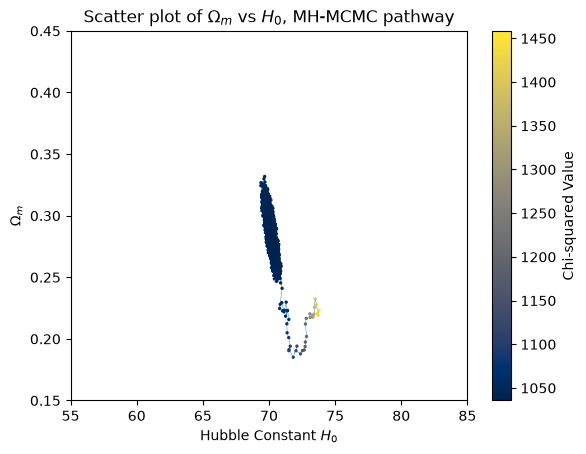

In [ ]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

In [ ]:

# mcmc_df = pd.read_csv("mcmc100000@260624.csv")
print(mcmc_df.head())


#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.1*final_chi_sq].index[0]
print(first_valid_index)

# Trim the DataFrame from the first valid index onward
mcmc_df = mcmc_df.iloc[first_valid_index:].reset_index(drop=True)

print(mcmc_df)


    Omega_m         H0       Chi_sq  Type
0  0.223310  73.791352  1458.561469   2.0
1  0.221044  73.685564  1421.850530   1.0
2  0.219250  73.703187  1420.886087   1.0
3  0.227661  73.594001  1418.642744   1.0
4  0.232487  73.487525  1405.961939   1.0
18
        Omega_m         H0       Chi_sq  Type
0      0.187832  72.382169  1141.468170   1.0
1      0.190359  72.040145  1116.714261   1.0
2      0.194137  72.111156  1118.631031   2.0
3      0.185105  71.831280  1114.488268   1.0
4      0.191380  71.521081  1102.054249   1.0
...         ...        ...          ...   ...
10911  0.313609  69.583045  1042.830173   2.0
10912  0.316754  69.706287  1042.037747   1.0
10913  0.318891  69.522786  1044.615402   2.0
10914  0.309734  69.508389  1045.150661   2.0
10915  0.313729  69.819394  1041.054809   1.0

[10916 rows x 4 columns]


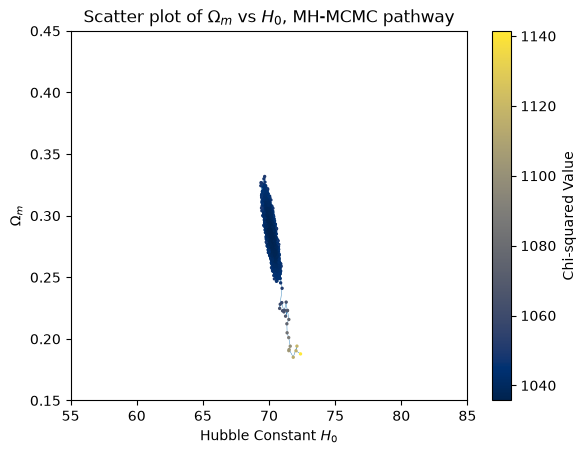

In [ ]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

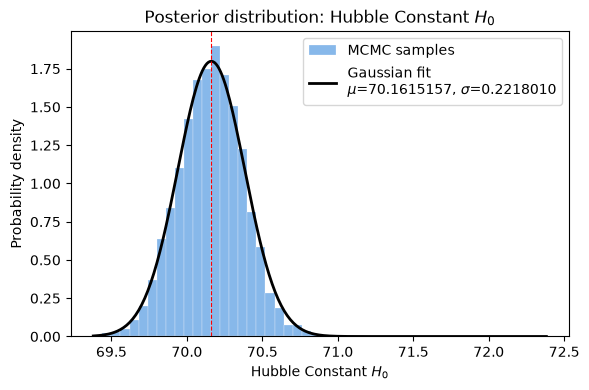

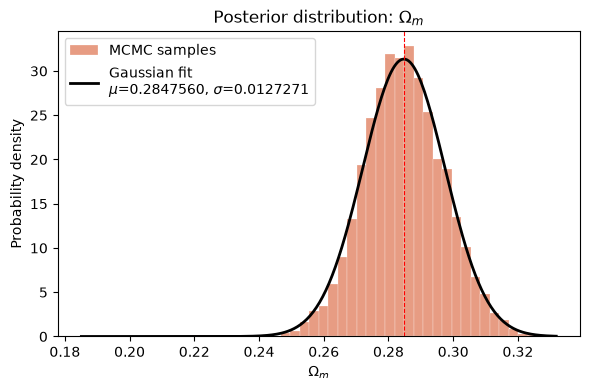

H0     = 70.16 +/- 0.22 km/s/Mpc
Omega_m = 0.285 +/- 0.013


In [ ]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD'):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)
 
    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)
 
    fig, ax = plt.subplots(figsize=(6, 4))
 
    # density=True normalizes the histogram so its area = 1, matching the
    # Gaussian pdf's area — otherwise the curve and bars are on different scales
    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')
 
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')
 
    ax.axvline(mu, color='red', linestyle='--', lw=0.8)
 
    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()
 
    return mu, sigma
 
 
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30')
 
print(f"H0     = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")

### Corner Plot


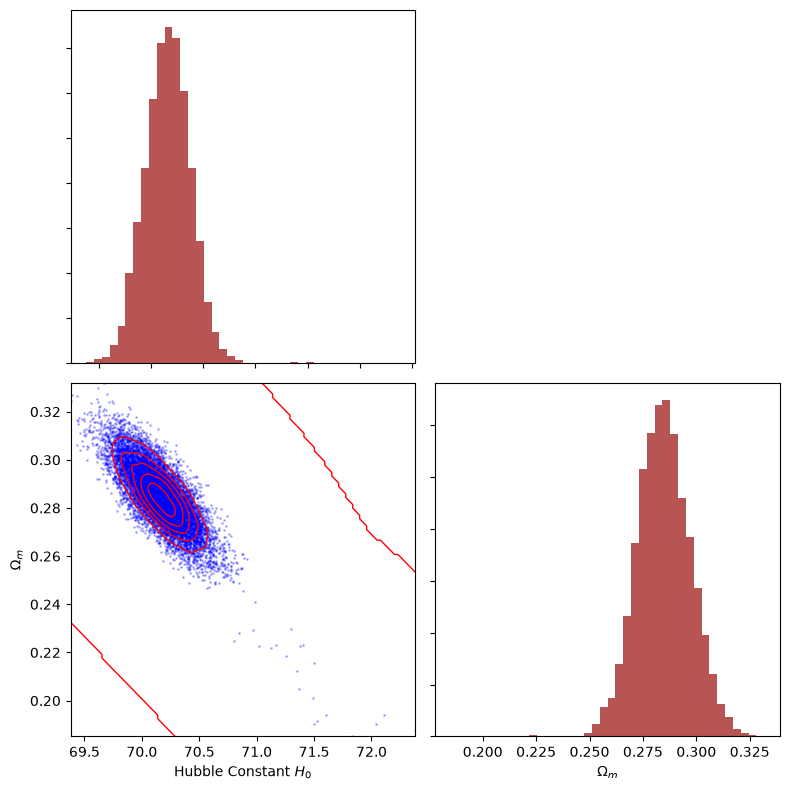

In [ ]:
from scipy.stats import gaussian_kde

data1 = mcmc_df[['H0', 'Omega_m']].to_numpy()
labels = ['Hubble Constant $H_0$', '$\u03A9_m$']
n = data1.shape[1]

fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(data1[:, i], bins=40, color='brown', alpha=0.8)
        elif i > j:
            x, y = data1[:, j], data1[:, i]

            # KDE(kernel density estimation) on a grid
            xy = np.vstack([x, y]) 

            kde = gaussian_kde(xy) 
            xmin, xmax = x.min(), x.max()
            ymin, ymax = y.min(), y.max()
            
            xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

            ax.scatter(x, y, s=1, color='blue', alpha=0.25)
            ax.contour(xx, yy, zz, levels=5, colors='red', linewidths=1)
        else:
            ax.axis('off')

        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

In [ ]:
import corner

figure = corner.corner(data1, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 1},
                       title_fmt=".2f", color='green', hist_kwargs={"color": "lightblue"})

NameError: name 'data1' is not defined

## MCMC for 3 parameters (H_0, Omega_m and Omega_r)

In [ ]:
def Hubble3(z, H0, omega_m, omega_r):
    return H0 * np.sqrt(omega_r * (1 + z)**4
                        + omega_m * (1 + z)**3
                        + (1 - omega_m - omega_r))

def integrand3(z, H0, omega_m, omega_r):
    return c / Hubble3(z, H0, omega_m, omega_r)

def DISTANCE_MODULUS3(z, H0, omega_m, omega_r):
    D_c, _ = integrate.quad(integrand3, 0, z, args=(H0, omega_m, omega_r))
    D_L = D_c * (1 + z)
    return 5 * np.log10(D_L) + 25

def CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev,
                   domega_m, dH0, domega_r,
                   omega_m_range, H0_range, omega_r_range):
    omega_m_new = omega_m_prev + domega_m * np.random.normal(0, 1)
    H0_new = H0_prev + dH0 * np.random.normal(0, 1)
    omega_r_new = omega_r_prev + domega_r * np.random.normal(0, 1)
    if (omega_m_range[0] <= omega_m_new <= omega_m_range[1]
        and H0_range[0] <= H0_new <= H0_range[1]
        and omega_r_range[0] <= omega_r_new <= omega_r_range[1]):
        return omega_m_new, H0_new, omega_r_new
    return CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev, domega_m, dH0, domega_r,
                          omega_m_range, H0_range, omega_r_range)

In [ ]:
omega_r_range = [0, 0.005]
delta_omega_r = 10**-5

mcmc_df3 = pd.DataFrame(columns=['H0', 'Omega_m', 'Omega_r', 'Chi_sq', 'Type'])

omega_m_prev = np.random.uniform(*omega_m_range)
H0_prev = np.random.uniform(*H0_range)
omega_r_prev = np.random.uniform(*omega_r_range)
print(f'Initial values: Omega_m={omega_m_prev:.3f}, H0={H0_prev:.2f}, Omega_r={omega_r_prev*10**5:.3f}e-5')

chi_sq1 = chi_sq(data['dist_mod'],
                 [DISTANCE_MODULUS3(z, H0_prev, omega_m_prev, omega_r_prev) for z in data['zcmb']],
                 data['dmb'])

for nstep in range(N_iterations):
    omega_m_new, H0_new, omega_r_new = CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev,
                                                      delta_omega_m, delta_H0, delta_omega_r,
                                                      omega_m_range, H0_range, omega_r_range)
    chi_sq2 = chi_sq(data['dist_mod'],
                     [DISTANCE_MODULUS3(z, H0_new, omega_m_new, omega_r_new) for z in data['zcmb']],
                     data['dmb'])

    if chi_sq2 <= chi_sq1:
        omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
        type_val = 1
        mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
        print(f'{nstep}) -- type 1, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0, 1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
            type_val = 2
            mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
            print(f'{nstep}) -- type 2, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
            # rejected — no append, no print

print("\nomega_m_Final, H0_Final, omega_r_Final:", omega_m_prev, H0_prev, omega_r_prev)
print('Final Chi_sq value:', chi_sq1)

Initial values: Omega_m=0.325, H0=59.22, Omega_r=225.298e-5
1) -- type 1, omega_m: 0.3298513244039831, H0 = 59.2602613366908, omega_r = 0.002247417094647075, chi_sq: 8046.7361873341415
2) -- type 1, omega_m: 0.3249115229757479, H0 = 59.433636469899625, omega_r = 0.002252093336812039, chi_sq: 7870.680241616331
3) -- type 1, omega_m: 0.32487783170727125, H0 = 59.663087547564515, omega_r = 0.002258212564190503, chi_sq: 7541.304939309022
4) -- type 1, omega_m: 0.3268907562049485, H0 = 59.78665394600077, omega_r = 0.0022765402731134156, chi_sq: 7336.503428476606
5) -- type 1, omega_m: 0.32469792756014093, H0 = 59.88911964282977, omega_r = 0.0022748162066229603, chi_sq: 7227.965472645379
6) -- type 1, omega_m: 0.3208465592427203, H0 = 60.379765616345345, omega_r = 0.0022730464609151237, chi_sq: 6628.77963884336
7) -- type 1, omega_m: 0.32498266698808237, H0 = 60.3983327849947, omega_r = 0.002252689455264256, chi_sq: 6545.975924114311
8) -- type 1, omega_m: 0.3267350971696041, H0 = 60.4309395

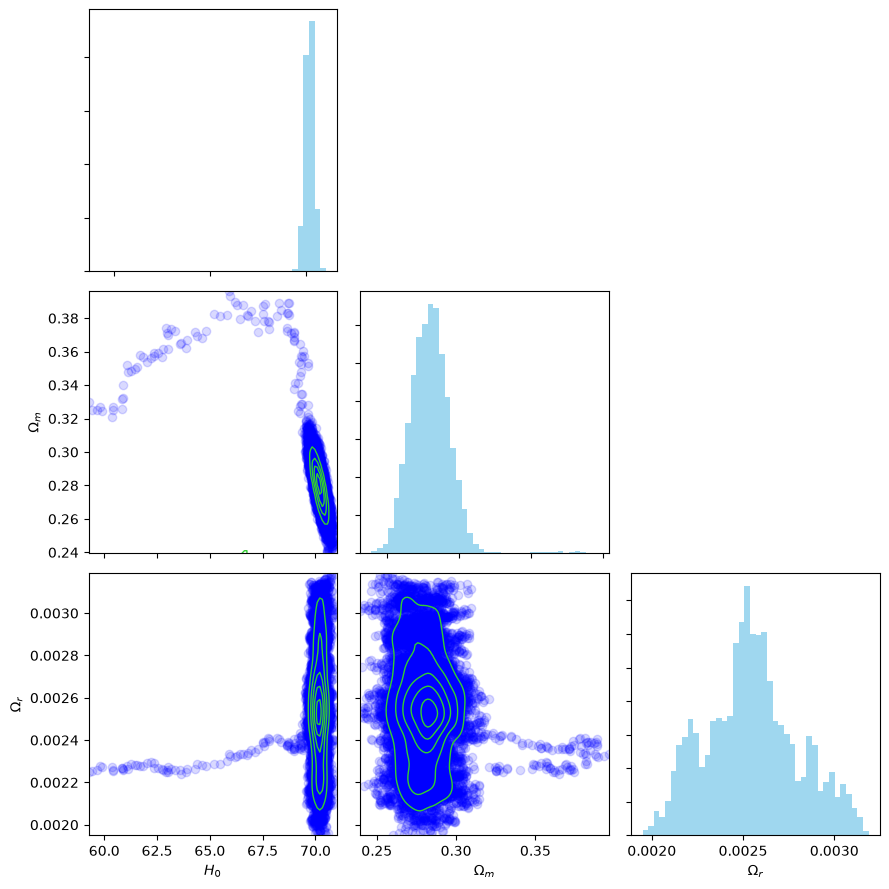

In [ ]:
from scipy.stats import gaussian_kde

samples = mcmc_df3[['H0', 'Omega_m', 'Omega_r']].to_numpy()   # shape (N_accepted, 3)
labels = ['$H_0$', '$\\Omega_m$', '$\\Omega_r$']
n = samples.shape[1]

#density = kde(np.vstack([x, y])) 
fig, axes = plt.subplots(n, n, figsize=(9, 9))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=40, color='skyblue', alpha=0.8 )
        elif i > j:
            x, y = samples[:, j], samples[:, i]
            kde = gaussian_kde(np.vstack([x, y]))
            xx, yy = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax.scatter(x, y, c='blue', alpha=0.15)  #ax.scatter(x, y, c=density, cmap='magma', alpha=0.8)
            ax.contour(xx, yy, zz, levels=5, colors='limegreen', linewidths=1)
        else:
            ax.axis('off')

        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

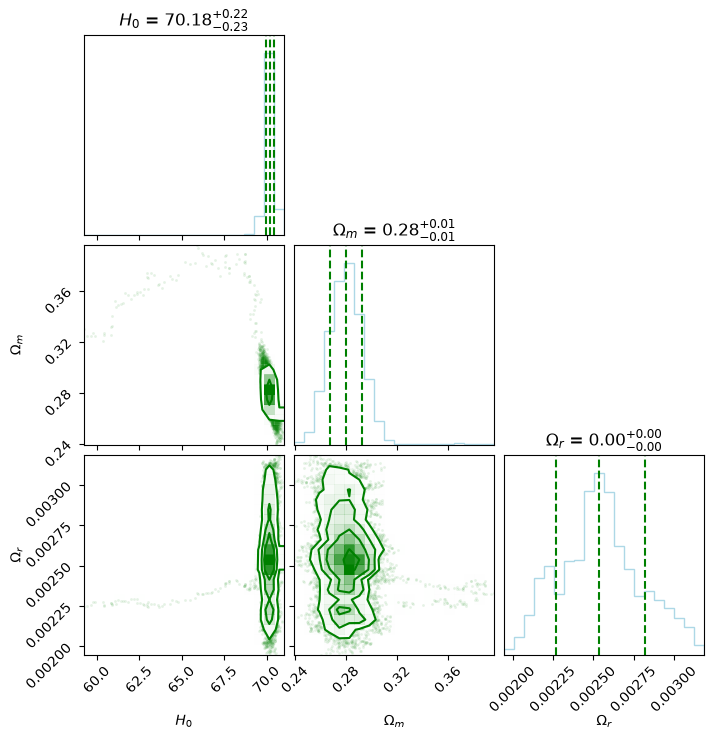

In [ ]:
figure = corner.corner(samples, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".2f", color='green', hist_kwargs={"color": "lightblue"})

In [ ]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df3['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df3['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30')
Or_mean, Or_std = plot_hist_with_gaussian(mcmc_df3['Omega_r'], '$\\Omega_r$',
                                           color='#4CAF50')

print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"Omega_r = {Or_mean:.7f} +/- {Or_std:.7f}")